In [1]:
from scripts.analysis import Analysis
import numpy as np
from scipy.constants import e, c, epsilon_0

import matplotlib.pyplot as plt

PyHEADTAIL v1.16.5


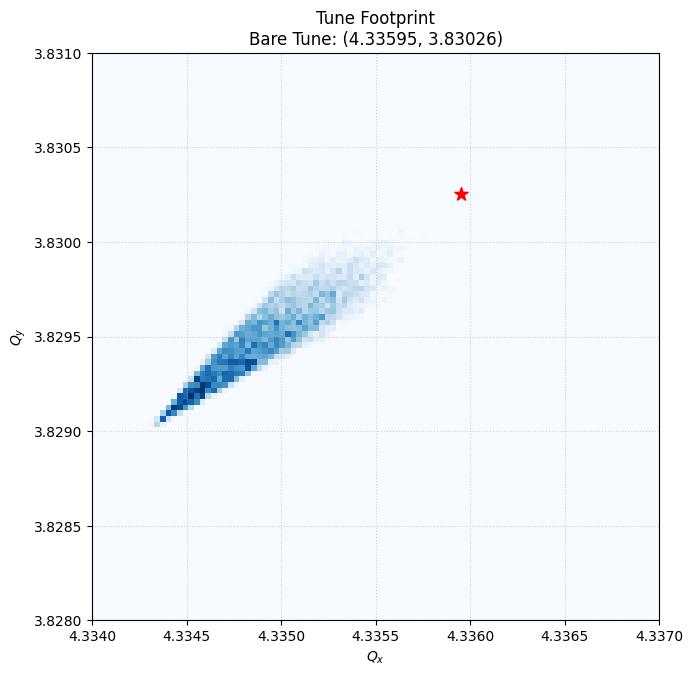

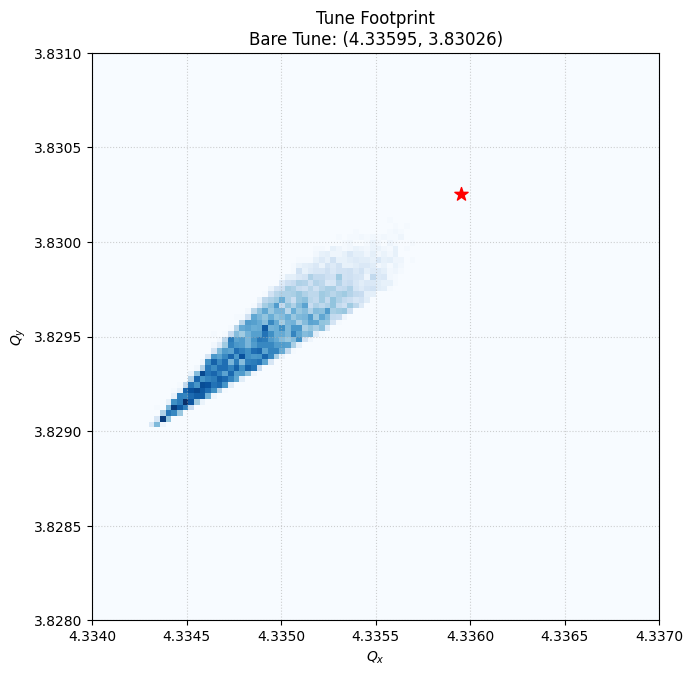

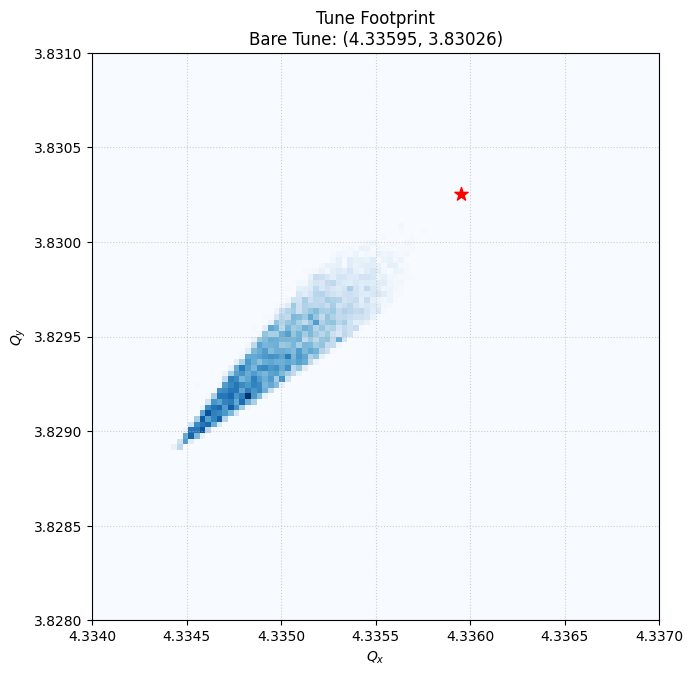

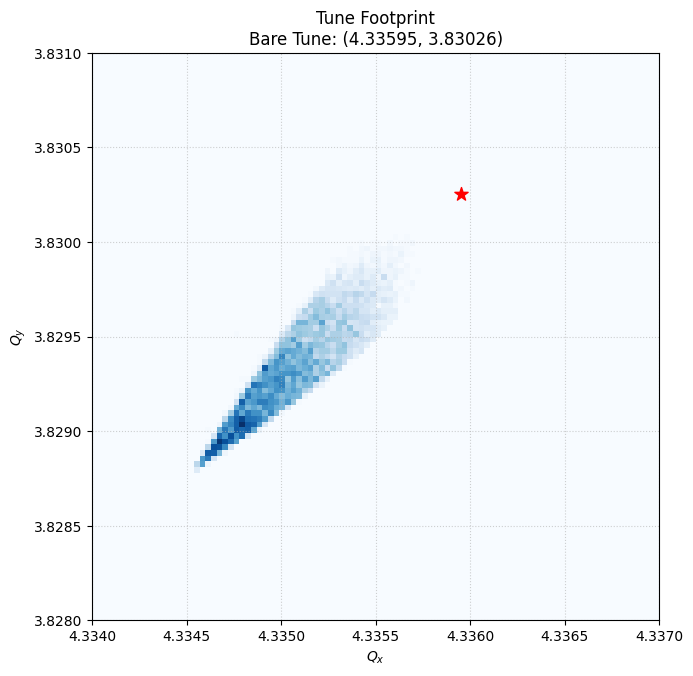

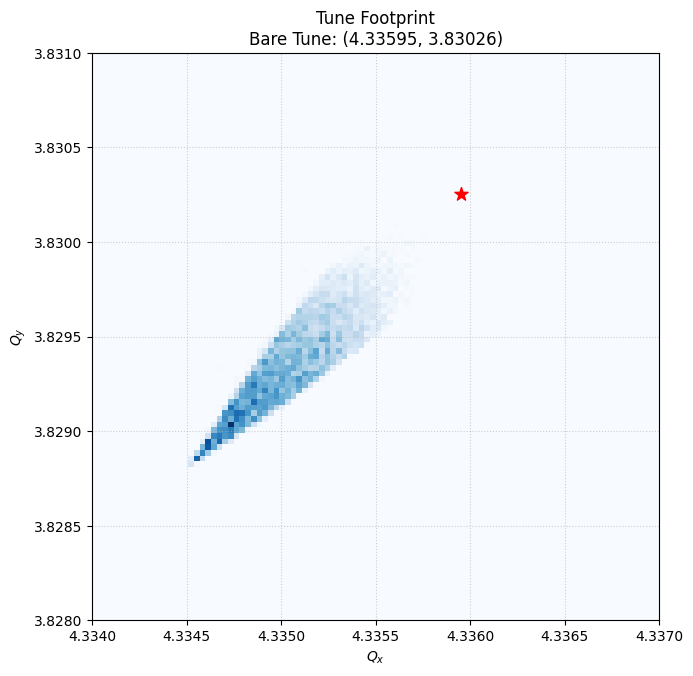

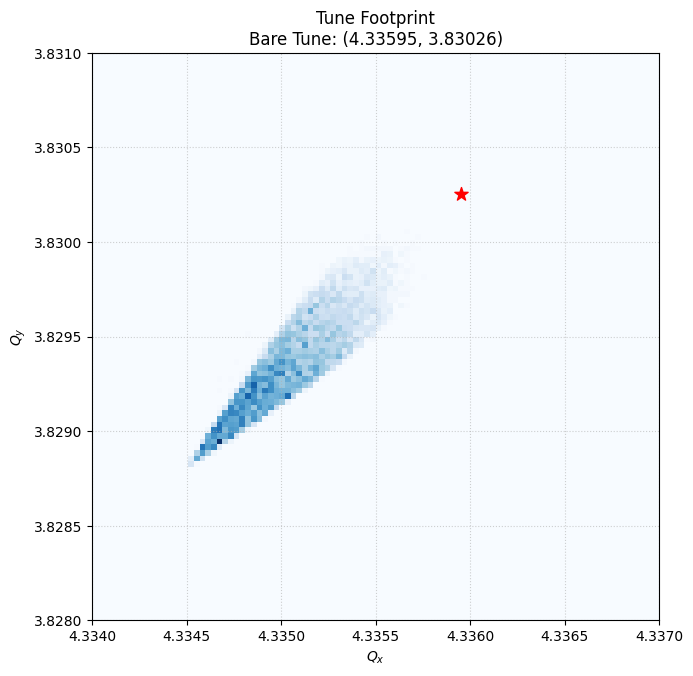

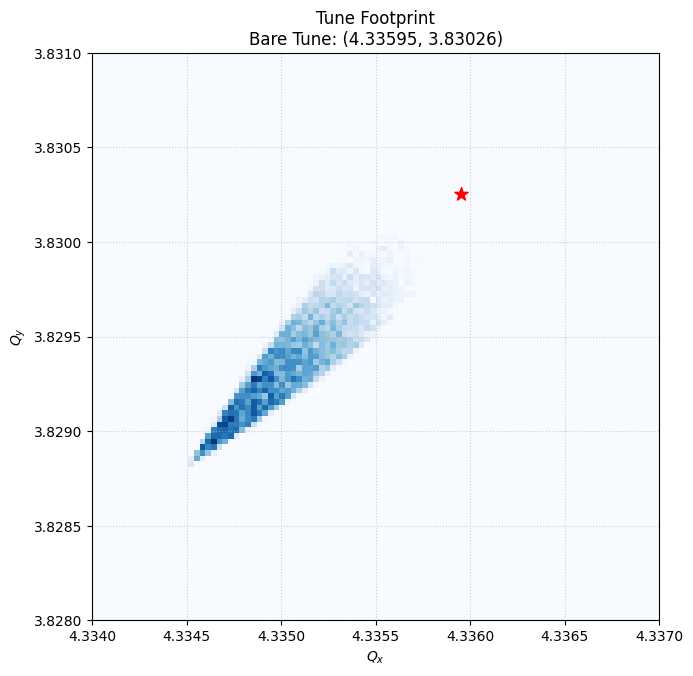

In [2]:
n_int  = [5, 10, 20, 50, 100, 200, 500] 
shift_x_list = []
shift_y_list = []
expected_shift_x_list = []
expected_shift_y_list = []
R = 26 # ISIS sync radius
p0c = 0.37033168 * 1e9 # Injection momenta (constant through sim)

for i in n_int:
    a = Analysis(f'int_var_4/{str(i)}')
    a.tune_histogram(x_lims=(4.334,4.337), y_lims=(3.828,3.831), show=True)
    
    shift_x = -(np.max(a.qx - a.get_tune('x'))%1)
    shift_y = -(np.max(a.qy - a.get_tune('y'))%1)
    shift_x_list.append(shift_x)
    shift_y_list.append(shift_y)

    _lambda = 5e9/(2*np.pi*R)
    K_sc = e*_lambda/(2*np.pi*epsilon_0 * a.beta * a.gamma**2 * p0c) # Space charge perveance
    
    expected_shift_x = - 2 * K_sc * R**2 / (4*a.sigma_x*(a.sigma_x + a.sigma_y) * a.qx)
    expected_shift_y = - 2 * K_sc * R**2 / (4*a.sigma_y*(a.sigma_x + a.sigma_y) * a.qy)
    expected_shift_x_list.append(expected_shift_x)
    expected_shift_y_list.append(expected_shift_y)

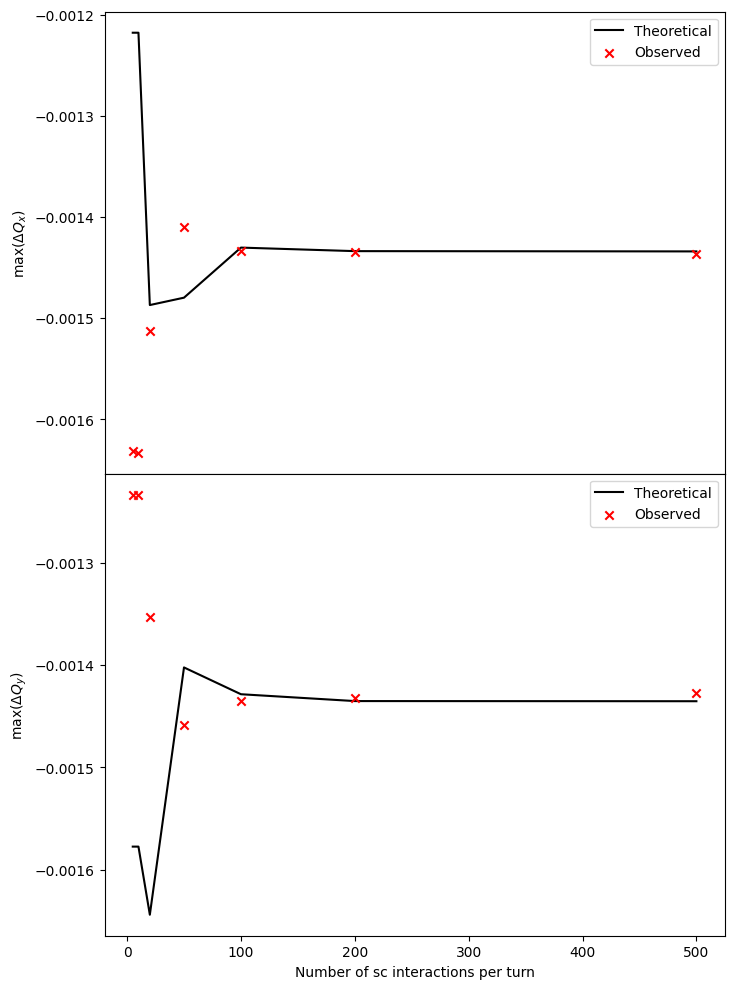

In [3]:
fig, axs = plt.subplots(2, figsize=(8,12), sharex=True)
axs[0].plot(n_int, np.array(expected_shift_x_list)*1.2936, zorder=1, label='Theoretical', c='k')
axs[0].scatter(n_int, shift_x_list, label='Observed', marker='x', c='r')
axs[0].set_ylabel(r'$\text{max}(\Delta Q_x)$')
axs[0].legend()

axs[1].plot(n_int, np.array(expected_shift_y_list)*1.1189, zorder=1, label='Theoretical', c='k')
axs[1].scatter(n_int, shift_y_list, label='Observed', marker='x', c='r')
axs[1].set_xlabel('Number of sc interactions per turn')
axs[1].set_ylabel(r'$\text{max}(\Delta Q_y)$')
axs[1].legend()

plt.subplots_adjust(hspace=0)
